# Évaluation YOLO26n-cls (S1) → D2

**Objectif.** Tester le modèle **YOLO26n-cls** entraîné sur le Scénario 1 (terrain Sherbrooke) sur les données complètes du Scénario 2 (iNaturalist global).

- **Modèle** : `1er_yolo26n-cls.pt` (dans `1er scénario_herbe_a_poux_yolo11ncls/Modeles/`)
- **Données** : `Photos_Positifs/` + `Photos_Negatifs/` du dossier `2e scénario_herbe_a_poux_yolo11ncls`

**Mapping des classes.**
- `Photos_Positifs/` → vérité terrain = `ambrosia`
- `Photos_Negatifs/` → vérité terrain = `non_ambrosia`

**Validité méthodologique.** Les images du Scénario 2 n'ont jamais été vues pendant l'entraînement du modèle S1 — la cross-évaluation mesure donc la généralisation du modèle vers le domaine global iNaturalist.


## 📦 Installation

In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.3 MB/s eta 0:00:00


> Si c'est la **première installation** de la session, redémarre le runtime puis relance à partir de la cellule suivante.

## ⚙️ Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, cohen_kappa_score,
)
from ultralytics import YOLO
from tqdm.auto import tqdm
import torch

GDRIVE = '/content/drive/MyDrive'
S1_DIR = os.path.join(GDRIVE, '1er scénario_herbe_a_poux_yolo11ncls')
S2_DIR = os.path.join(GDRIVE, '2e scénario_herbe_a_poux_yolo11ncls')

# Modèle YOLO26n-cls entraîné sur S1 — dossier séparé dédié au YOLO26n
YOLO26N_DIR = os.path.join(GDRIVE, '1er scénario_herbe_a_poux_yolo26ncls')
MODEL_PATH = os.path.join(YOLO26N_DIR, 'Modeles', '1er_yolo26n-cls.pt')

# Données cibles — Scénario 2 complet
D2_POS = os.path.join(S2_DIR, 'Photos_Positifs')
D2_NEG = os.path.join(S2_DIR, 'Photos_Negatifs')

OUT_DIR = os.path.join(GDRIVE, 'Cross_Evaluation_YOLO26n_S1_D2')
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE   = 224
BATCH_SIZE = 256
RUN_TAG    = datetime.now().strftime('%Y%m%d_%H%M%S')

print('Vérification des chemins :')
for label, p in [
    ('Modèle YOLO26n S1', MODEL_PATH),
    ('D2 Positifs      ', D2_POS),
    ('D2 Négatifs      ', D2_NEG),
]:
    status = '✓' if os.path.exists(p) else '✗ MANQUANT'
    print(f'  {status}  {label} : {p}')

print(f'\nRun    : {RUN_TAG}')
print(f'Sortie : {OUT_DIR}')


Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Vérification des chemins :
  ✓  Modèle YOLO26n S1 : /content/drive/MyDrive/1er scénario_herbe_a_poux_yolo26ncls/Modeles/1er_yolo26n-cls.pt
  ✓  D2 Positifs       : /content/drive/MyDrive/2e scénario_herbe_a_poux_yolo11ncls/Photos_Positifs
  ✓  D2 Négatifs       : /content/drive/MyDrive/2e scénario_herbe_a_poux_yolo11ncls/Photos_Negatifs

Run    : 20260413_142020
Sortie : /content/drive/MyDrive/Cross_Evaluation_YOLO26n_S1_D2


## 🧩 Fonction d'évaluation

L'évaluation prend en entrée les deux dossiers bruts (positifs + négatifs) et les mappe vers les labels du modèle. Les prédictions YOLO utilisent toujours les noms de classes d'**entraînement** (`ambrosia` / `non_ambrosia`), donc on mappe :

- `Photos_Positifs/` → index de `ambrosia` dans `model.names`
- `Photos_Negatifs/` → index de `non_ambrosia` dans `model.names`

Cela garantit que le mapping reste correct même si les classes du modèle sont dans un ordre différent.


In [ ]:
IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def lister_images(dossier: str) -> list:
    """Liste récursive et triée des images dans un dossier."""
    if not os.path.exists(dossier):
        return []
    return sorted([
        str(p) for p in Path(dossier).rglob('*')
        if p.suffix.lower() in IMG_EXT
    ])


def preparer_dataset_yolo(pos_dir: str, neg_dir: str, class_names: list) -> str:
    """Crée une arborescence YOLO-cls temporaire (train/val/test) avec des
    symlinks vers les images Drive. model.val(split='test') lira le test set.
    Les dossiers train/val sont vides mais requis par YOLO."""
    import tempfile, shutil

    # Détermine quelle classe du modèle est ambrosia / non_ambrosia
    idx_ambr = next(
        (i for i, n in enumerate(class_names) if n.lower().startswith('ambrosia')),
        None
    )
    idx_neg = next(
        (i for i, n in enumerate(class_names) if 'non' in n.lower() or 'neg' in n.lower()),
        None
    )
    if idx_ambr is None or idx_neg is None:
        raise ValueError(f'Impossible de mapper les classes : {class_names}')

    name_ambr = class_names[idx_ambr]
    name_neg  = class_names[idx_neg]

    # Dossier temporaire
    tmp_root = tempfile.mkdtemp(prefix='yolo_eval_')
    # Create all directories first
    for split in ('train', 'val', 'test'):
        for cls in class_names:
            os.makedirs(os.path.join(tmp_root, split, cls), exist_ok=True)

    # Symlinks du test set
    pos_imgs = lister_images(pos_dir)
    neg_imgs = lister_images(neg_dir)
    n_pos = len(pos_imgs)
    n_neg = len(neg_imgs)

    test_pos_dir = os.path.join(tmp_root, 'test', name_ambr)
    test_neg_dir = os.path.join(tmp_root, 'test', name_neg)

    for i, src in enumerate(pos_imgs):
        ext = Path(src).suffix.lower()
        dst = os.path.join(test_pos_dir, f'{i:06d}{ext}')
        try:
            os.symlink(src, dst)
        except FileExistsError:
            pass

    for i, src in enumerate(neg_imgs):
        ext = Path(src).suffix.lower()
        dst = os.path.join(test_neg_dir, f'{i:06d}{ext}')
        try:
            os.symlink(src, dst)
        except FileExistsError:
            pass

    # Add a minimal set of images to train/val to satisfy YOLO's internal checks
    # even if we're only evaluating on 'test'.
    # Use the first positive and negative image as placeholders for train/val splits.
    first_pos_img = pos_imgs[0] if n_pos > 0 else None
    first_neg_img = neg_imgs[0] if n_neg > 0 else None

    for split in ('train', 'val'):
        # For ambrosia class
        train_val_ambr_dir = os.path.join(tmp_root, split, name_ambr)
        if first_pos_img:
            ext = Path(first_pos_img).suffix.lower()
            dst = os.path.join(train_val_ambr_dir, f'dummy_001{ext}')
            try:
                os.symlink(first_pos_img, dst)
            except FileExistsError:
                pass

        # For non_ambrosia class
        train_val_neg_dir = os.path.join(tmp_root, split, name_neg)
        if first_neg_img:
            ext = Path(first_neg_img).suffix.lower()
            dst = os.path.join(train_val_neg_dir, f'dummy_001{ext}')
            try:
                os.symlink(first_neg_img, dst)
            except FileExistsError:
                pass

    return tmp_root, n_pos, n_neg, idx_ambr, idx_neg

## 🧪 Exécution des cross-évaluations

In [ ]:
# YOLO26n entraîné sur S1, testé sur toutes les photos du Scénario 2
res_M1_D2 = evaluer(MODEL_PATH, D2_POS, D2_NEG, 'YOLO26n (S1) → D2')



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  YOLO26n (S1) → D2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Modèle : 1er_yolo26n-cls.pt
  Pos    : /content/drive/MyDrive/2e scénario_herbe_a_poux_yolo11ncls/Photos_Positifs
  Neg    : /content/drive/MyDrive/2e scénario_herbe_a_poux_yolo11ncls/Photos_Negatifs
  Classes modèle : ['ambrosia', 'non_ambrosia']
  Dataset préparé en 0.6s — 5454 pos + 5458 neg = 10912 images
  Lancement model.val() sur device=0 ...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /tmp/yolo_eval_k_r_sv_v/train... found 2 images in 2 classes ✅ 
val: /tmp/yolo_eval_k_r_sv_v/val... found 2 images in 2 classes ✅ 
test: /tmp/yolo_eval_k_r_sv_v/test... found 10912 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.3±0.1 ms, read: 1.5±1.0 MB/s, size: 1494.6 KB)
test: Scanning /tmp/yolo_eval_k_r_sv_v/test... 10912 ima

  Probabilités [YOLO26n (S1) → D2]:   0%|                                | 0/10912 [00:00<?, ?img/s]

  Probabilités calculées en 960.1s

  Accuracy  :  90.55%
  F1-Macro  : 0.9055
  Precision : 0.9058
  Recall    : 0.9055
  Kappa     : 0.8110
  ROC-AUC   : 0.9672

              precision    recall  f1-score   support

    ambrosia     0.8955    0.9180    0.9067      5454
non_ambrosia     0.9160    0.8930    0.9044      5458

    accuracy                         0.9055     10912
   macro avg     0.9058    0.9055    0.9055     10912
weighted avg     0.9058    0.9055    0.9055     10912



## 📊 Tableau comparatif

In [ ]:
resultats = [res_M1_D2]

df = pd.DataFrame([{
    'Évaluation': r['nom'],
    'N images'  : r['n_images'],
    'N Pos'     : r['n_pos'],
    'N Neg'     : r['n_neg'],
    'Accuracy'  : f'{r["accuracy"]*100:.2f}%',
    'F1-Macro'  : f'{r["f1_macro"]:.4f}',
    'Precision' : f'{r["precision"]:.4f}',
    'Recall'    : f'{r["recall"]:.4f}',
    'Kappa'     : f'{r["kappa"]:.4f}',
    'ROC-AUC'   : f'{r["auc"]:.4f}' if r['auc'] is not None else 'n/a',
} for r in resultats])
print(df.to_string(index=False))

df.to_csv(os.path.join(OUT_DIR, f'resume_cross_eval_{RUN_TAG}.csv'), index=False)


       Évaluation  N images  N Pos  N Neg Accuracy F1-Macro Precision Recall  Kappa ROC-AUC
YOLO26n (S1) → D2     10912   5454   5458   90.55%   0.9055    0.9058 0.9055 0.8110  0.9672


## 📈 Visualisations

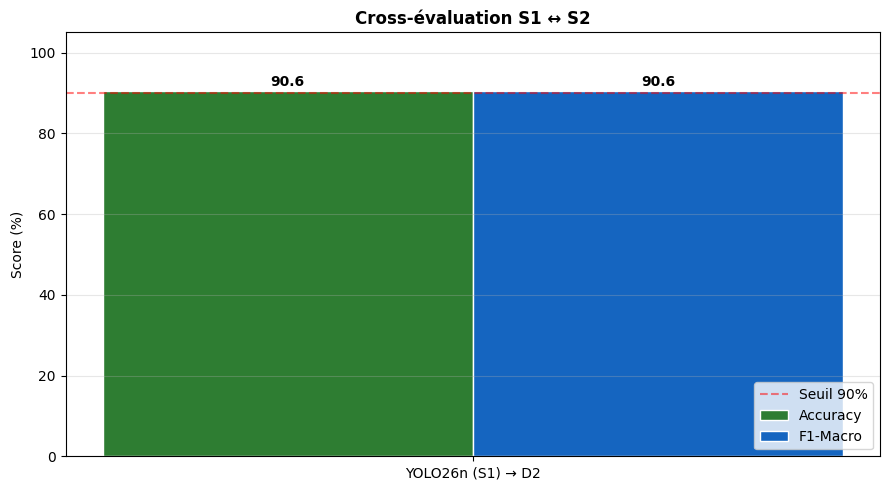

In [ ]:
# Barres comparatives Accuracy / F1
fig, ax = plt.subplots(figsize=(9, 5))
noms = [r['nom'] for r in resultats]
accs = [r['accuracy']*100 for r in resultats]
f1s  = [r['f1_macro']*100 for r in resultats]

x = np.arange(len(noms))
w = 0.35
b1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='#2E7D32', edgecolor='white')
b2 = ax.bar(x + w/2, f1s,  w, label='F1-Macro', color='#1565C0', edgecolor='white')

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.axhline(90, color='red', linestyle='--', alpha=0.5, label='Seuil 90%')
ax.set_xticks(x)
ax.set_xticklabels(noms, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.set_title('Cross-évaluation S1 ↔ S2', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'barres_{RUN_TAG}.png'), dpi=150)
plt.show()


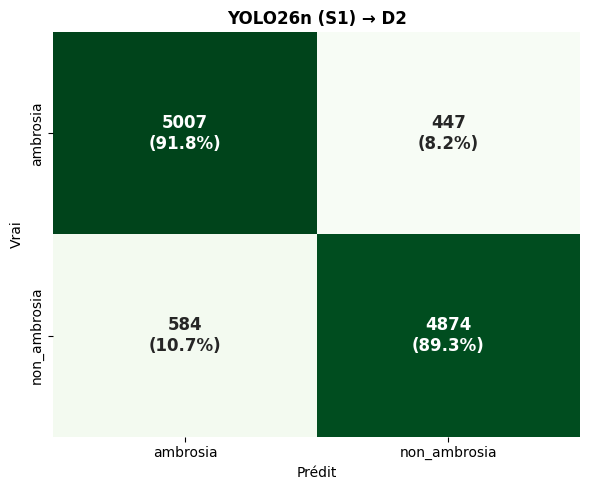

In [ ]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
res = resultats[0]
cm = np.array(res['confusion'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot = [[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
          for j in range(cm.shape[1])] for i in range(cm.shape[0])]
sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Greens',
            xticklabels=res['class_names'], yticklabels=res['class_names'],
            cbar=False, ax=ax, annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title(res['nom'], fontweight='bold')
ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'confusion_{RUN_TAG}.png'), dpi=150)
plt.show()


## 📊 Distribution des prédictions correctes / incorrectes par classe

Pour chaque cross-évaluation et chaque classe (`ambrosia`, `non_ambrosia`), on compte combien d'images sont correctement classifiées vs mal classifiées. C'est une lecture complémentaire des matrices de confusion : les barres empilées mettent en évidence si un modèle échoue surtout sur la classe positive ou négative.


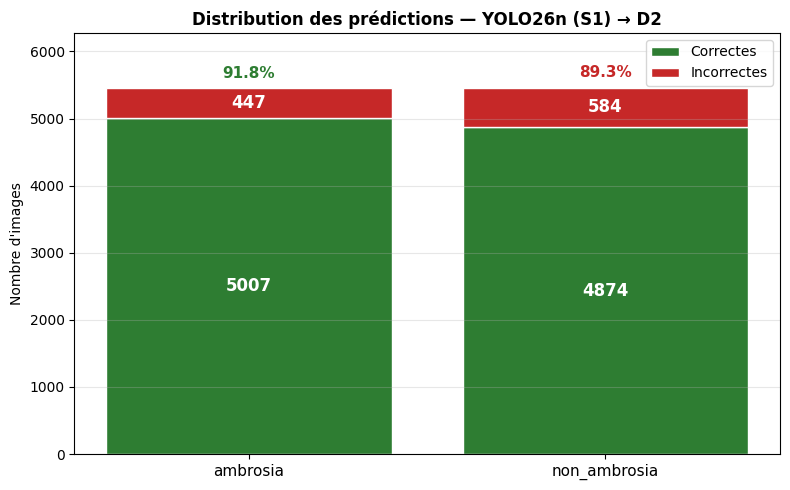


  ambrosia        :  5007 correctes /   447 incorrectes  ( 91.8% réussite sur 5454 images)
  non_ambrosia    :  4874 correctes /   584 incorrectes  ( 89.3% réussite sur 5458 images)


In [ ]:
# Distribution correct/incorrect par classe
fig, ax = plt.subplots(figsize=(8, 5))
res = resultats[0]
cm = np.array(res['confusion'])
class_names = res['class_names']
corrects   = np.diag(cm)
incorrects = cm.sum(axis=1) - corrects

x = np.arange(len(class_names))
ax.bar(x, corrects,   color='#2E7D32', edgecolor='white', label='Correctes')
ax.bar(x, incorrects, bottom=corrects, color='#C62828', edgecolor='white', label='Incorrectes')

totals = corrects + incorrects
for i, (ok, ko, tot) in enumerate(zip(corrects, incorrects, totals)):
    pct = (ok / tot * 100) if tot > 0 else 0
    if ok > 0:
        ax.text(i, ok / 2, f'{int(ok)}', ha='center', va='center',
                color='white', fontweight='bold', fontsize=12)
    if ko > 0:
        ax.text(i, ok + ko / 2, f'{int(ko)}', ha='center', va='center',
                color='white', fontweight='bold', fontsize=12)
    ax.text(i, tot + max(totals) * 0.02, f'{pct:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11,
            color='#2E7D32' if pct >= 90 else '#C62828')

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_title(f'Distribution des prédictions — {res["nom"]}',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Nombre d\'images')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(totals) * 1.15)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'distribution_{RUN_TAG}.png'), dpi=150)
plt.show()

# Tableau récapitulatif
print()
for cls in res['class_names']:
    i = res['class_names'].index(cls)
    ok  = int(np.diag(cm)[i])
    tot = int(cm.sum(axis=1)[i])
    ko  = tot - ok
    pct = ok / tot * 100 if tot > 0 else 0
    print(f'  {cls:<15} : {ok:5d} correctes / {ko:5d} incorrectes  '
          f'({pct:5.1f}% réussite sur {tot} images)')


## 💾 Sauvegarde JSON

In [ ]:
resume = {
    'run_tag'   : RUN_TAG,
    'img_size'  : IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'modele'    : MODEL_PATH,
    'donnees'   : {'D2_pos': D2_POS, 'D2_neg': D2_NEG},
    'resultats' : {'YOLO26n_S1_D2': res_M1_D2},
}

out_json = os.path.join(OUT_DIR, f'cross_eval_{RUN_TAG}.json')
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(resume, f, indent=2, ensure_ascii=False)
print(f'✓ Résumé JSON : {out_json}')


✓ Résumé JSON : /content/drive/MyDrive/Cross_Evaluation_YOLO26n_S1_D2/cross_eval_20260413_142020.json


## ✅ Vérification de la sauvegarde sur Drive

Bloc ajouté pour diagnostiquer les problèmes de sauvegarde : liste le contenu réel du dossier de sortie, affiche la taille de chaque fichier, et force le flush du cache Drive pour que les fichiers apparaissent immédiatement dans l'interface web.


In [ ]:
# Vérification : lister tout ce qui a été réellement écrit dans OUT_DIR
import os, time

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Contenu du dossier de sortie')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  {OUT_DIR}')
print()

if not os.path.exists(OUT_DIR):
    print('  ✗ Le dossier n\'existe pas !')
else:
    fichiers = sorted(os.listdir(OUT_DIR))
    if not fichiers:
        print('  ✗ Dossier vide')
    else:
        total_ko = 0
        for f in fichiers:
            chemin = os.path.join(OUT_DIR, f)
            taille = os.path.getsize(chemin)
            total_ko += taille / 1024
            mtime = time.strftime('%H:%M:%S', time.localtime(os.path.getmtime(chemin)))
            print(f'  ✓ {f:<50} {taille/1024:>8.1f} KB  (écrit à {mtime})')
        print(f'\n  Total : {len(fichiers)} fichier(s) — {total_ko:.1f} KB')

# Force la synchronisation Drive pour que les fichiers apparaissent dans l\'interface web
print('\n  Flush Drive en cours...')
try:
    from google.colab import drive
    drive.flush_and_unmount()
    time.sleep(2)
    drive.mount('/content/drive', force_remount=False)
    print('  ✓ Drive synchronisé — les fichiers devraient maintenant être visibles.')
    print(f'\n  Ouvre manuellement : https://drive.google.com/drive/my-drive')
    print(f'  puis cherche le dossier : {os.path.basename(OUT_DIR)}')
except Exception as e:
    print(f'  ⚠ Flush échoué : {e}')
    print('  Les fichiers sont écrits mais peuvent prendre quelques minutes à apparaître.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Contenu du dossier de sortie
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  /content/drive/MyDrive/Cross_Evaluation_YOLO26n_S1_D2

  ✓ barres_20260413_142020.png                             36.9 KB  (écrit à 15:30:26)
  ✓ confusion_20260413_142020.png                          39.5 KB  (écrit à 15:30:51)
  ✓ cross_eval_20260413_142020.json                         0.9 KB  (écrit à 15:31:10)
  ✓ distribution_20260413_142020.png                       51.9 KB  (écrit à 15:31:02)
  ✓ resume_cross_eval_20260413_142020.csv                   0.2 KB  (écrit à 15:30:22)

  Total : 5 fichier(s) — 129.3 KB

  Flush Drive en cours...
Mounted at /content/drive
  ✓ Drive synchronisé — les fichiers devraient maintenant être visibles.

  Ouvre manuellement : https://drive.google.com/drive/my-drive
  puis cherche le dossier : Cross_Evaluation_YOLO26n_S1_D2
